In [1]:
#pip install pandas numpy matplotlib seaborn scikit-learn statsmodels streamlit

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

In [3]:
# Load dataset
df = pd.read_csv("Data/HHS_Unaccompanied_Alien_Children_Program.csv")

In [4]:
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Date                                             720 non-null    object 
 1   Children apprehended and placed in CBP custody*  720 non-null    float64
 2   Children in CBP custody                          720 non-null    float64
 3   Children transferred out of CBP custody          720 non-null    float64
 4   Children in HHS Care                             720 non-null    object 
 5   Children discharged from HHS Care                720 non-null    float64
dtypes: float64(4), object(2)
memory usage: 55.0+ KB


In [6]:
# Remove empty rows
df = df.dropna(subset=["Date"])

In [7]:
# Convert date column
df["Date"] = pd.to_datetime(df["Date"])

In [8]:
# Convert date column
df["Date"] = pd.to_datetime(df["Date"])

# Clean numeric columns
cols = [
    "Children in HHS Care",
    "Children apprehended and placed in CBP custody*",
    "Children in CBP custody",
    "Children transferred out of CBP custody",
    "Children discharged from HHS Care"
]

for col in cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
    )
    
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [9]:
# Sort chronologically
df = df.sort_values("Date")

In [10]:
# Set datetime index
df = df.set_index("Date")

In [11]:
#final check
print(df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 720 entries, 2023-01-12 to 2025-12-21
Data columns (total 5 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Children apprehended and placed in CBP custody*  720 non-null    float64
 1   Children in CBP custody                          720 non-null    float64
 2   Children transferred out of CBP custody          720 non-null    float64
 3   Children in HHS Care                             720 non-null    int64  
 4   Children discharged from HHS Care                720 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 33.8 KB
None


In [12]:
print(df.head())

            Children apprehended and placed in CBP custody*  \
Date                                                          
2023-01-12                                             33.0   
2023-01-22                                             32.0   
2023-01-23                                             32.0   
2023-01-24                                             47.0   
2023-01-25                                             20.0   

            Children in CBP custody  Children transferred out of CBP custody  \
Date                                                                           
2023-01-12                     53.0                                     34.0   
2023-01-22                     49.0                                     39.0   
2023-01-23                     50.0                                     39.0   
2023-01-24                     42.0                                     47.0   
2023-01-25                     22.0                                     41.0  

In [13]:
print(df.describe())

       Children apprehended and placed in CBP custody*  \
count                                       720.000000   
mean                                         93.523611   
std                                          72.646625   
min                                           0.000000   
25%                                          12.000000   
50%                                          99.000000   
75%                                         147.250000   
max                                         333.000000   

       Children in CBP custody  Children transferred out of CBP custody  \
count               720.000000                               720.000000   
mean                171.494444                               128.668056   
std                 126.354965                                97.322012   
min                   7.000000                                 0.000000   
25%                  36.000000                                14.000000   
50%                 193.000

In [14]:
print(df.isnull().sum())

Children apprehended and placed in CBP custody*    0
Children in CBP custody                            0
Children transferred out of CBP custody            0
Children in HHS Care                               0
Children discharged from HHS Care                  0
dtype: int64


In [15]:
import matplotlib.pyplot as plt

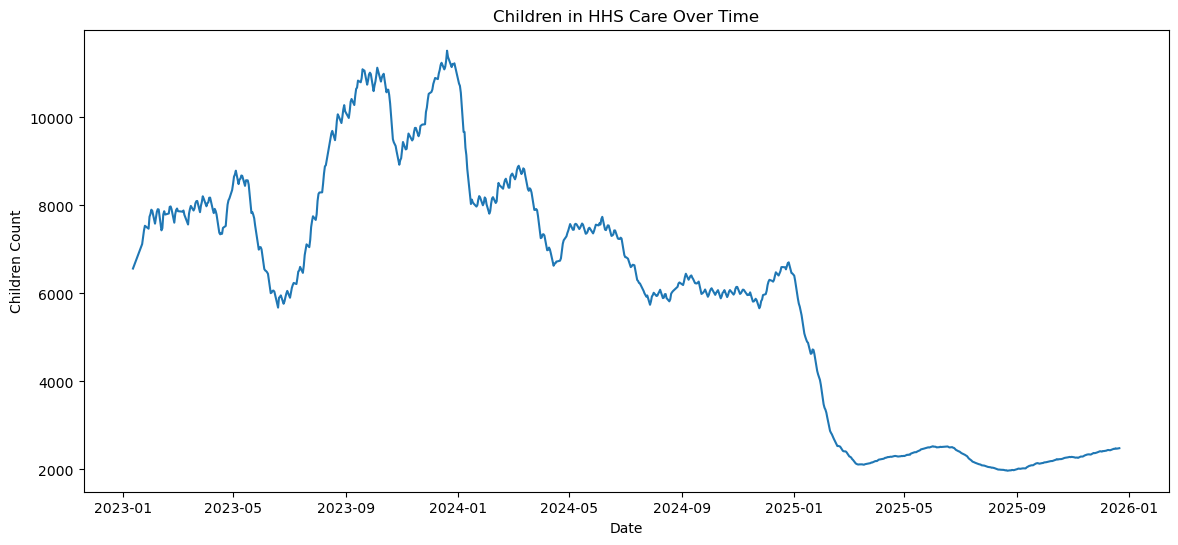

In [16]:
plt.figure(figsize=(14,6))

plt.plot(df.index, df["Children in HHS Care"])

plt.title("Children in HHS Care Over Time")
plt.xlabel("Date")
plt.ylabel("Children Count")

plt.show()

In [17]:
df["net_flow"] = (
    df["Children transferred out of CBP custody"]
    -
    df["Children discharged from HHS Care"]
)

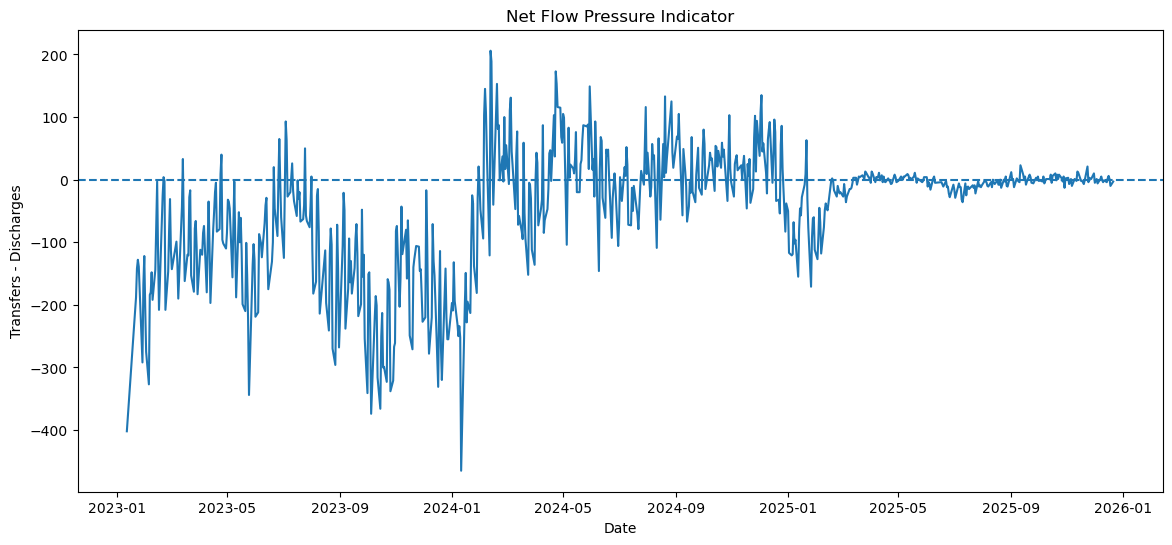

In [18]:
plt.figure(figsize=(14,6))

plt.plot(df.index, df["net_flow"])

plt.axhline(0, linestyle="--")

plt.title("Net Flow Pressure Indicator")
plt.xlabel("Date")
plt.ylabel("Transfers - Discharges")

plt.show()

In [19]:
import seaborn as sns

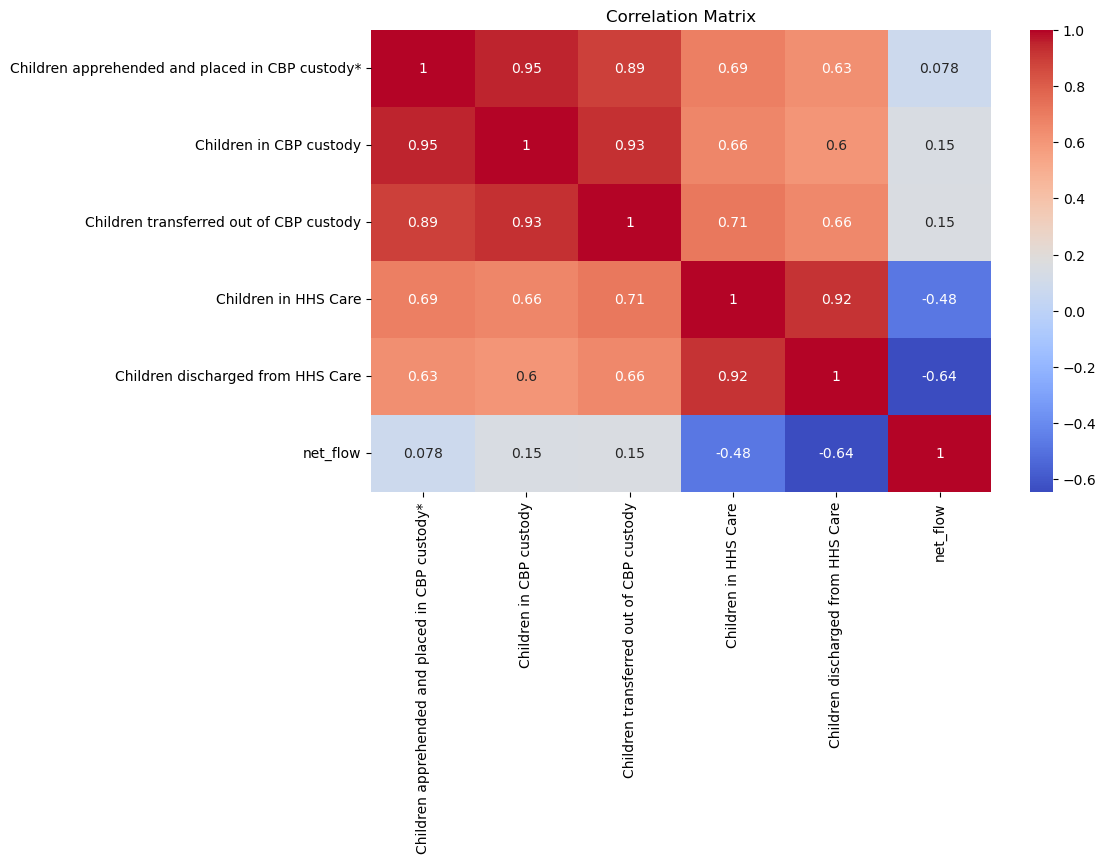

In [20]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

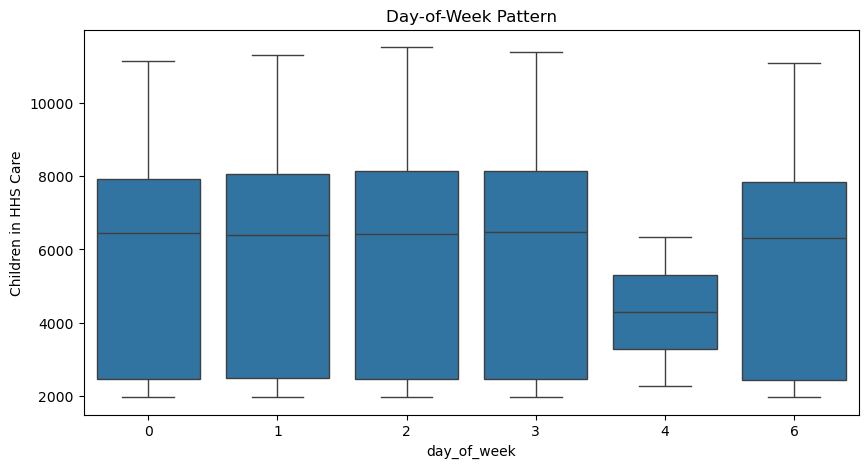

In [21]:
df["day_of_week"] = df.index.dayofweek

plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["day_of_week"],
    y=df["Children in HHS Care"]
)

plt.title("Day-of-Week Pattern")

plt.show()

In [22]:
# Lag features
df["lag_1"] = df["Children in HHS Care"].shift(1)
df["lag_7"] = df["Children in HHS Care"].shift(7)
df["lag_14"] = df["Children in HHS Care"].shift(14)

In [23]:
# Rolling statistics
df["rolling_mean_7"] = df["Children in HHS Care"].rolling(7).mean()
df["rolling_std_7"] = df["Children in HHS Care"].rolling(7).std()


In [24]:
# Additional pressure indicators
df["net_flow_lag_3"] = df["net_flow"].shift(3)
df["net_flow_lag_7"] = df["net_flow"].shift(7)

In [25]:
# Month feature
df["month"] = df.index.month

In [26]:
# Remove NA values caused by shifting
df = df.dropna()

In [27]:
print(df.head())

            Children apprehended and placed in CBP custody*  \
Date                                                          
2023-02-09                                            124.0   
2023-02-12                                             92.0   
2023-02-13                                            186.0   
2023-02-14                                            154.0   
2023-02-15                                             91.0   

            Children in CBP custody  Children transferred out of CBP custody  \
Date                                                                           
2023-02-09                    234.0                                    161.0   
2023-02-12                    203.0                                    173.0   
2023-02-13                    259.0                                    172.0   
2023-02-14                    225.0                                    220.0   
2023-02-15                    199.0                                    172.0  

In [28]:
target = "Children in HHS Care"

In [29]:
features = [
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_std_7",
    "net_flow",
    "net_flow_lag_3",
    "net_flow_lag_7",
    "day_of_week",
    "month"
]

In [30]:
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

print(train.shape)
print(test.shape)

(564, 15)
(142, 15)


In [31]:
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [32]:
naive_preds = test["lag_1"]

In [33]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

In [34]:
import numpy as np

In [35]:
def evaluate_model(y_true, y_pred, model_name):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mape = np.mean(
        np.abs((y_true - y_pred) / y_true)
    ) * 100

    print(f"{model_name}")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")
    print("-" * 30)

In [36]:
evaluate_model(
    y_test,
    naive_preds,
    "Naive Baseline"
)

Naive Baseline
MAE: 10.42
RMSE: 14.21
MAPE: 0.46%
------------------------------


In [37]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

In [38]:
evaluate_model(
    y_test,
    rf_preds,
    "Random Forest"
)

Random Forest
MAE: 61.38
RMSE: 82.23
MAPE: 2.83%
------------------------------


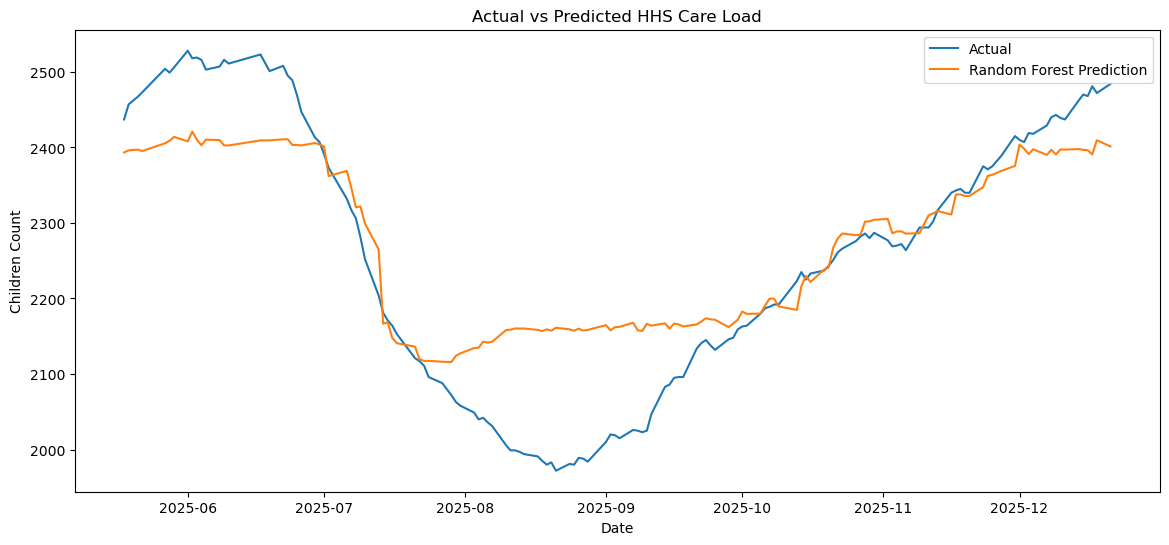

In [39]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test.index,
    y_test,
    label="Actual"
)

plt.plot(
    y_test.index,
    rf_preds,
    label="Random Forest Prediction"
)

plt.title("Actual vs Predicted HHS Care Load")

plt.xlabel("Date")
plt.ylabel("Children Count")

plt.legend()

plt.show()

In [40]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr.fit(X_train, y_train)

gbr_preds = gbr.predict(X_test)

In [41]:
evaluate_model(
    y_test,
    gbr_preds,
    "Gradient Boosting"
)

Gradient Boosting
MAE: 61.69
RMSE: 81.62
MAPE: 2.86%
------------------------------


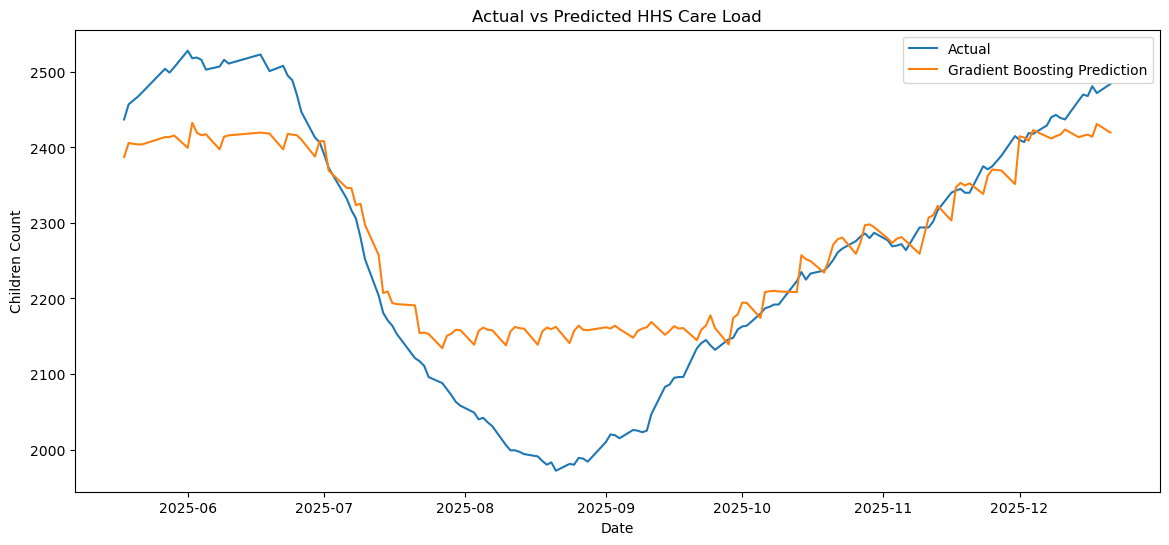

In [42]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test.index,
    y_test,
    label="Actual"
)

plt.plot(
    y_test.index,
    gbr_preds,
    label="Gradient Boosting Prediction"
)

plt.title("Actual vs Predicted HHS Care Load")

plt.xlabel("Date")
plt.ylabel("Children Count")

plt.legend()

plt.show()

In [43]:
import warnings

warnings.filterwarnings("ignore")

In [44]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [45]:
sarima_model = SARIMAX(
    y_train,
    order=(1,1,1),
    seasonal_order=(1,1,1,7)
)

sarima_fit = sarima_model.fit(disp=False)

c:\Users\shanb\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\shanb\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [46]:
sarima_preds = sarima_fit.forecast(
    steps=len(y_test)
)

c:\Users\shanb\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [47]:
evaluate_model(
    y_test,
    sarima_preds,
    "SARIMA"
)

SARIMA
MAE: 828.42
RMSE: 921.67
MAPE: nan%
------------------------------


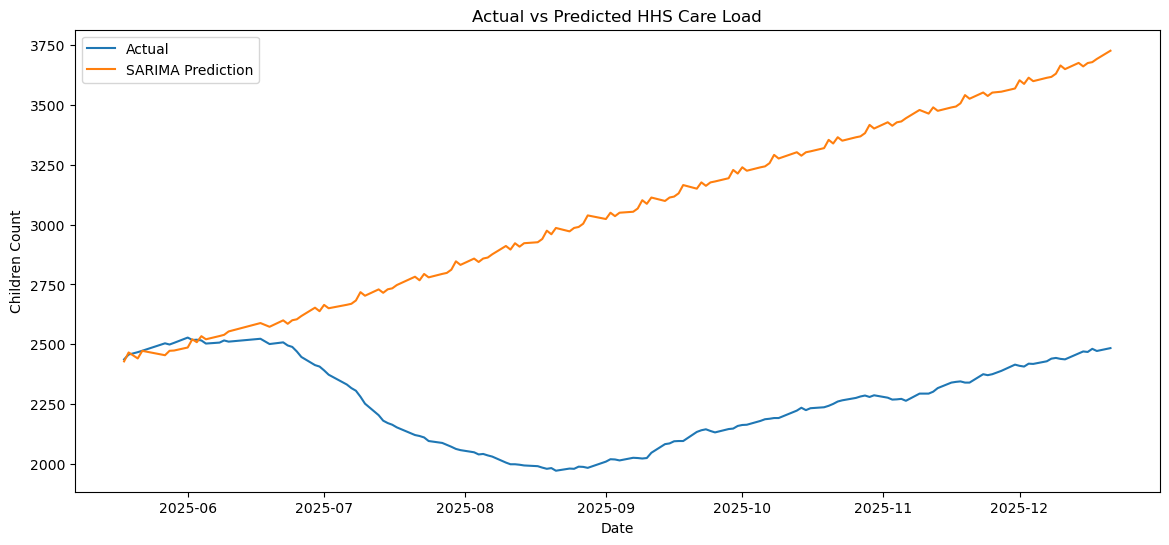

In [48]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test.index,
    y_test,
    label="Actual"
)

plt.plot(
    y_test.index,
    sarima_preds,
    label="SARIMA Prediction"
)

plt.title("Actual vs Predicted HHS Care Load")

plt.xlabel("Date")
plt.ylabel("Children Count")

plt.legend()

plt.show()

In [49]:
future_forecast = sarima_fit.forecast(steps=30)

print(future_forecast)

564    2428.575787
565    2465.855529
566    2440.874801
567    2472.555509
568    2454.313061
569    2472.775390
570    2473.924419
571    2486.514221
572    2520.784737
573    2508.674673
574    2533.814760
575    2520.869885
576    2534.430300
577    2539.456172
578    2553.586729
579    2588.613581
580    2573.075194
581    2599.902248
582    2585.524750
583    2600.340335
584    2604.308011
585    2617.995998
586    2652.787007
587    2638.115540
588    2664.461547
589    2650.425096
590    2664.873457
591    2669.083547
592    2682.851735
593    2717.668486
Name: predicted_mean, dtype: float64


c:\Users\shanb\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


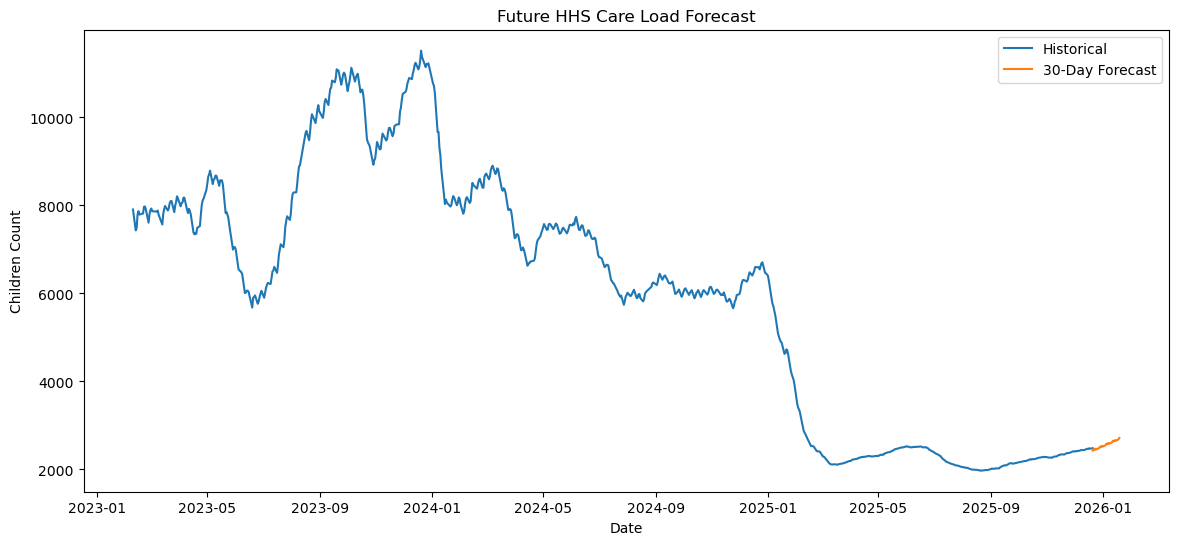

In [50]:
plt.figure(figsize=(14,6))

plt.plot(
    df.index,
    df[target],
    label="Historical"
)

future_dates = pd.date_range(
    start=df.index[-1],
    periods=30,
    freq="D"
)

plt.plot(
    future_dates,
    future_forecast,
    label="30-Day Forecast"
)

plt.title("Future HHS Care Load Forecast")

plt.xlabel("Date")
plt.ylabel("Children Count")

plt.legend()

plt.show()

In [51]:
forecast_object = sarima_fit.get_forecast(steps=30)

forecast_mean = forecast_object.predicted_mean

conf_int = forecast_object.conf_int()

c:\Users\shanb\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


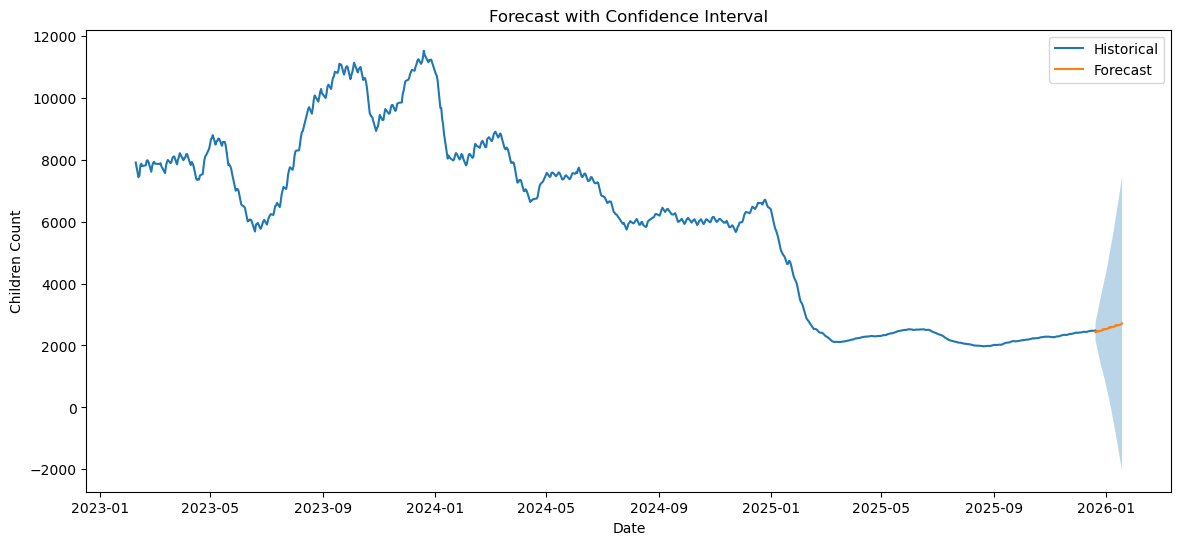

In [52]:
plt.figure(figsize=(14,6))

plt.plot(
    df.index,
    df[target],
    label="Historical"
)

plt.plot(
    future_dates,
    forecast_mean,
    label="Forecast"
)

plt.fill_between(
    future_dates,
    conf_int.iloc[:,0],
    conf_int.iloc[:,1],
    alpha=0.3
)

plt.title("Forecast with Confidence Interval")

plt.xlabel("Date")
plt.ylabel("Children Count")

plt.legend()

plt.show()

In [53]:
stress_threshold = df["net_flow"].quantile(0.90)

print(stress_threshold)

50.5


In [54]:
df["stress_alert"] = (
    df["net_flow"] > stress_threshold
)

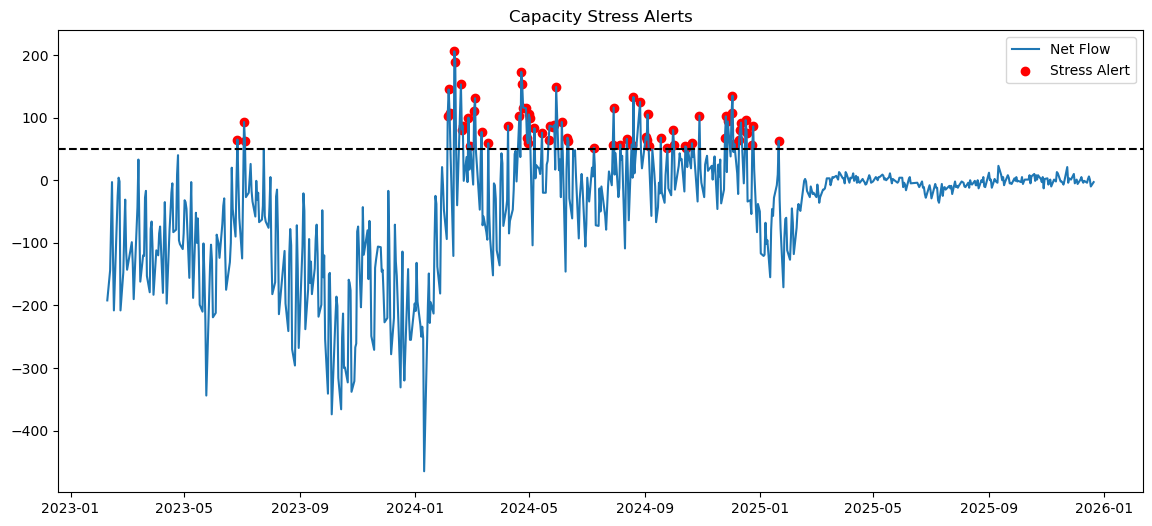

In [55]:
plt.figure(figsize=(14,6))

plt.plot(
    df.index,
    df["net_flow"],
    label="Net Flow"
)

plt.scatter(
    df[df["stress_alert"]].index,
    df[df["stress_alert"]]["net_flow"],
    color="red",
    label="Stress Alert"
)

plt.axhline(
    stress_threshold,
    linestyle="--",
    color="black"
)

plt.title("Capacity Stress Alerts")

plt.legend()

plt.show()